In [3]:
import sys
print(sys.executable)

c:\Users\COTTA\anaconda3\python.exe


In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from dython.nominal import associations

In [3]:
df_segment = pd.read_parquet('./data/train/1_회원정보_train.parquet')

In [54]:
df_segment

,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,3,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,2,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,3,1,1,0,1,2,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,2,70대이상,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,노년생활,39
2399996,201812,TRAIN_399996,2,50대,3,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),24
2399997,201812,TRAIN_399997,1,30대,2,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,18
2399998,201812,TRAIN_399998,1,40대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),27


In [4]:
df = pd.read_parquet('./data/train/3_승인매출정보_train.parquet')
df

,기준년월,ID,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,...,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,승인거절건수_R3M,승인거절건수_한도초과_R3M,승인거절건수_BL_R3M,승인거절건수_입력오류_R3M,승인거절건수_기타_R3M,이용금액대
0,201807,TRAIN_000000,20180719,20180713,20180719,10101,20180203,20180709,20180713,11,...,0,0,0,0,3,3,0,0,0,01.100만원+
1,201807,TRAIN_000001,20180719,20180719,20170728,20170327,10101,20180719,20171231,13,...,0,0,0,0,3,3,0,0,0,03.30만원+
2,201807,TRAIN_000002,20180706,20180706,20180706,20151119,20141230,20180706,20180627,12,...,0,0,0,0,0,0,0,0,0,01.100만원+
3,201807,TRAIN_000003,20180721,20180715,20180721,10101,20141111,20180704,20180715,6,...,0,0,0,0,3,3,0,0,0,01.100만원+
4,201807,TRAIN_000004,20180124,20180124,10101,10101,20180512,20180124,10101,-2,...,0,0,0,0,0,0,0,0,0,09.미사용
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,20181220,20181220,10101,10101,20181212,20181220,20160501,2,...,0,0,0,0,0,0,0,0,0,09.미사용
2399996,201812,TRAIN_399996,20181202,20181202,10101,20170112,10101,20181202,20180112,10,...,0,0,0,0,0,0,0,0,0,01.100만원+
2399997,201812,TRAIN_399997,20181230,20181230,10101,10101,20131124,20181230,20180919,10,...,0,0,0,0,0,0,0,0,0,02.50만원+
2399998,201812,TRAIN_399998,20161224,20161224,10101,10101,10101,20161224,20150122,-2,...,0,0,0,0,0,0,0,0,0,09.미사용


In [5]:
# Segment 라벨 인코딩
if df_segment["Segment"].dtype == "object":
    df_segment["Segment"] = df_segment["Segment"].astype("category").cat.codes

In [6]:
df_segment

,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,...,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,3,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,2,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,3,1,1,0,1,2,...,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,2,70대이상,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,노년생활,39
2399996,201812,TRAIN_399996,2,50대,3,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(2),24
2399997,201812,TRAIN_399997,1,30대,2,1,1,0,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀출산기,18
2399998,201812,TRAIN_399998,1,40대,4,1,1,1,1,1,...,0,0,0,0개,0개,0개,0개,0,자녀성장(1),27


In [47]:
# 결측치 50% 이상인 것을 제외한다.
threshold = 0.5
valid_cols = df.columns[df.isnull().mean() < threshold]
reduced_df = df[valid_cols]

In [48]:
reduced_df.shape

(2400000, 394)

In [49]:
print(df.info())
print(reduced_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Columns: 406 entries, 기준년월 to 이용금액대
dtypes: float64(3), int64(385), object(18)
memory usage: 7.3+ GB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Columns: 394 entries, 기준년월 to 이용금액대
dtypes: float64(1), int64(385), object(8)
memory usage: 7.0+ GB
None


In [50]:
reduced_df['ID']

0          TRAIN_000000
1          TRAIN_000001
2          TRAIN_000002
3          TRAIN_000003
4          TRAIN_000004
               ...     
2399995    TRAIN_399995
2399996    TRAIN_399996
2399997    TRAIN_399997
2399998    TRAIN_399998
2399999    TRAIN_399999
Name: ID, Length: 2400000, dtype: object

In [11]:
# object 타입 중에서 'ID' 제외한 컬럼 제거
df_drop = [col for col in reduced_df.select_dtypes(include='object').columns if col != "ID"]
numeric_df = reduced_df.drop(columns=df_drop)

In [45]:
numeric_df

,기준년월,ID,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,...,승인거절건수_B0M,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,승인거절건수_R3M,승인거절건수_한도초과_R3M,승인거절건수_BL_R3M,승인거절건수_입력오류_R3M,승인거절건수_기타_R3M
0,201807,TRAIN_000000,20180719,20180713,20180719,10101,20180203,20180709,20180713,11,...,0,0,0,0,0,3,3,0,0,0
1,201807,TRAIN_000001,20180719,20180719,20170728,20170327,10101,20180719,20171231,13,...,0,0,0,0,0,3,3,0,0,0
2,201807,TRAIN_000002,20180706,20180706,20180706,20151119,20141230,20180706,20180627,12,...,0,0,0,0,0,0,0,0,0,0
3,201807,TRAIN_000003,20180721,20180715,20180721,10101,20141111,20180704,20180715,6,...,0,0,0,0,0,3,3,0,0,0
4,201807,TRAIN_000004,20180124,20180124,10101,10101,20180512,20180124,10101,-2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,201812,TRAIN_399995,20181220,20181220,10101,10101,20181212,20181220,20160501,2,...,0,0,0,0,0,0,0,0,0,0
2399996,201812,TRAIN_399996,20181202,20181202,10101,20170112,10101,20181202,20180112,10,...,0,0,0,0,0,0,0,0,0,0
2399997,201812,TRAIN_399997,20181230,20181230,10101,10101,20131124,20181230,20180919,10,...,0,0,0,0,0,0,0,0,0,0
2399998,201812,TRAIN_399998,20161224,20161224,10101,10101,10101,20161224,20150122,-2,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
numeric_df.to_parquet('./result/')

In [14]:
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Columns: 387 entries, 기준년월 to 승인거절건수_기타_R3M
dtypes: float64(1), int64(385), object(1)
memory usage: 6.9+ GB


In [46]:
numeric_df.isna().sum()

기준년월               0
ID                 0
최종이용일자_기본          0
최종이용일자_신판          0
최종이용일자_CA          0
                  ..
승인거절건수_R3M         0
승인거절건수_한도초과_R3M    0
승인거절건수_BL_R3M      0
승인거절건수_입력오류_R3M    0
승인거절건수_기타_R3M      0
Length: 387, dtype: int64

In [ ]:
# 1. ID 기준 정렬 (Segment만 정렬)
segment_series = df_segment[["ID", "Segment"]].sort_values("ID").reset_index(drop=True)
segment = segment_series["Segment"]

# 2. features만 추출
all_cols = [col for col in numeric_df.columns if col != "ID"]

# 3. ID 기준 정렬은 슬라이스마다 한 번만 사용 (ID 기준으로 먼저 인덱스 매핑)
id_sorted_idx = numeric_df["ID"].argsort().values
sorted_numeric_df = numeric_df.iloc[id_sorted_idx].reset_index(drop=True)

# 4. 컬럼 나누기 (190개씩)
chunk_size = 190
chunks = [all_cols[i:i+chunk_size] for i in range(0, len(all_cols), chunk_size)]

# 5. 상관계수 계산
corr_list = []

for cols in chunks:
    subset = sorted_numeric_df[cols]
    corr = subset.corrwith(segment)
    corr_list.append(corr)

# 6. 전체 결과 이어붙이기
correlations = pd.concat(corr_list).sort_values(key=lambda x: abs(x), ascending=False)

# 7. 상위 20개만 정리
top_corr_df = correlations.head(20).reset_index()
top_corr_df.columns = ["컬럼명", "상관계수"]

In [51]:
correlations

정상청구원금_B5M        -0.660738
정상청구원금_B0M        -0.634571
정상청구원금_B2M        -0.628078
이용금액_일시불_R12M     -0.595858
이용금액_일시불_B0M      -0.575032
                     ...   
이용금액_당사기타_B0M           NaN
이용건수_당사페이_B0M           NaN
이용건수_당사기타_B0M           NaN
승인거절건수_입력오류_B0M         NaN
승인거절건수_기타_B0M           NaN
Length: 386, dtype: float64

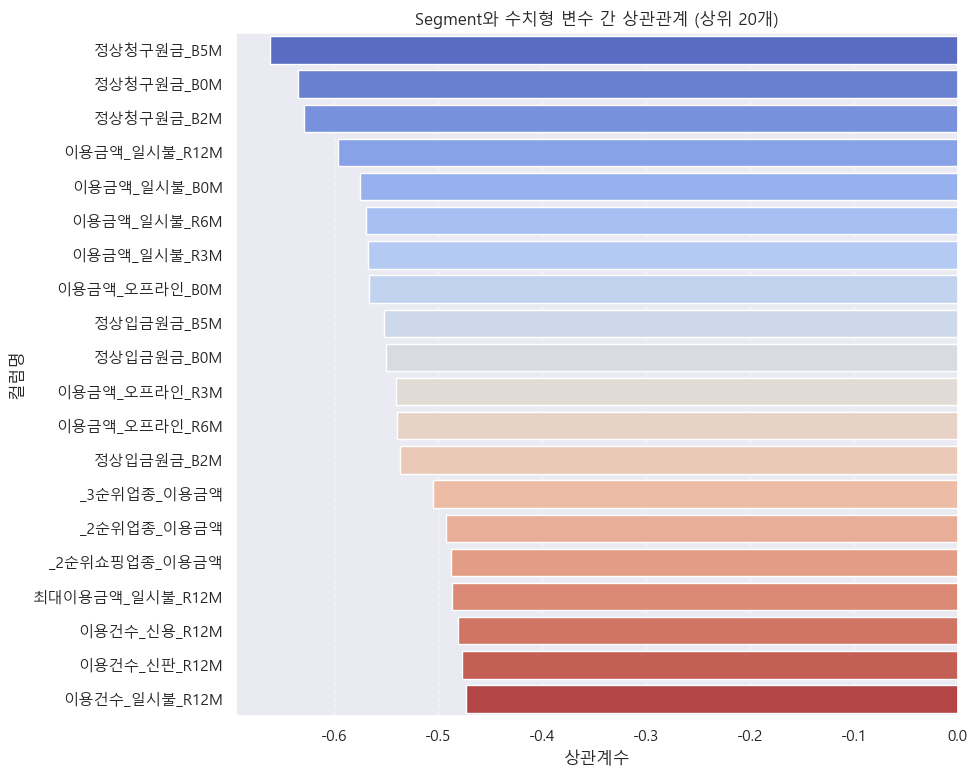

In [19]:
# 8. 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(x="상관계수", y="컬럼명", data=top_corr_df, palette="coolwarm")
plt.title("Segment와 수치형 변수 간 상관관계 (상위 20개)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# correlations: pd.Series → DataFrame 변환
correlations_df = correlations.reset_index()
correlations_df.columns = ["컬럼명", "상관계수"]

# CSV 저장
correlations_df.to_csv("./result/3_승인매출정보_상관계수_결측치_제거.csv", index=False)

In [52]:
correlations_df

,컬럼명,상관계수
0,정상청구원금_B5M,-0.660738
1,정상청구원금_B0M,-0.634571
2,정상청구원금_B2M,-0.628078
3,이용금액_일시불_R12M,-0.595858
4,이용금액_일시불_B0M,-0.575032
...,...,...
381,이용금액_당사기타_B0M,NaN
382,이용건수_당사페이_B0M,NaN
383,이용건수_당사기타_B0M,NaN
384,승인거절건수_입력오류_B0M,NaN


### 결측치 관련

In [21]:
df.shape

(2400000, 406)

`df`에서 결측치 50% 이상인 것 제외 : 12개 삭제

In [32]:
reduced_df.shape

(2400000, 394)

In [35]:
null_cols = reduced_df.columns[reduced_df.isnull().any()]
print(null_cols.tolist())

['_1순위업종', '_2순위업종', '_3순위업종', '_1순위쇼핑업종', '_2순위쇼핑업종', '_1순위교통업종']


In [37]:
reduced_df[null_cols].dtypes

_1순위업종      object
_2순위업종      object
_3순위업종      object
_1순위쇼핑업종    object
_2순위쇼핑업종    object
_1순위교통업종    object
dtype: object

`reduced_df`에서 null이 존재하는 컬럼을 조회해본 결과 6개가 있었고 전부 오브젝트 타입이었다.  
범주형은 전부 제외한 후 수치형 컬럼만 보려고 했던건데 결과적으로 결측치가 전부 제거되었다.  

`numeric_df`에서 결과적으로 컬럼 18개가 삭제됨

In [22]:
numeric_df.shape

(2400000, 387)